In [1]:
# 1. Import necessary libraries
import os
import librosa
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout


In [7]:
# 2. Define the data path and genres
DATA_PATH = r"../data"
GENRES = ['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock']


In [8]:
# 3. Feature extraction function
def extract_features(file_name):
    try:
        audio, sample_rate = librosa.load(file_name, res_type='kaiser_fast')
        mfccs = librosa.feature.mfcc(y=audio, sr=sample_rate, n_mfcc=128)
        mfccs_scaled = np.mean(mfccs.T, axis=0)
        return mfccs_scaled
    except Exception as e:
        print(f"Error encountered while parsing file: {file_name}")
        return 


In [9]:
# 4. Preprocess the dataset and extract features
def preprocess_data(data_path, genres):
    features = []
    labels = []
    
    for genre in genres:
        genre_path = os.path.join(data_path, genre)
        for file_name in os.listdir(genre_path):
            if file_name.endswith('.wav'):
                file_path = os.path.join(genre_path, file_name)
                data = extract_features(file_path)
                if data is not None:
                    features.append(data)
                    labels.append(genre)
    
    features_df = pd.DataFrame(features)
    features_df['label'] = labels
    return features_df

In [10]:
# 5. Load and preprocess data
features_df = preprocess_data(DATA_PATH, GENRES)
print(f"Total number of samples: {len(features_df)}")

C:\Users\Adrian\AppData\Local\Temp\ipykernel_14776\1212033669.py:4: UserWarning: PySoundFile failed. Trying audioread instead.
  audio, sample_rate = librosa.load(file_name, res_type='kaiser_fast')
c:\Users\Adrian\anaconda3\Lib\site-packages\librosa\core\audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


Error encountered while parsing file: ../data\jazz\jazz.00054.wav
Total number of samples: 999


In [11]:
# 6. Encode labels
encoder = LabelEncoder()
features_df['label'] = encoder.fit_transform(features_df['label'])

In [15]:
X = np.array(features_df.iloc[:, :-1].values)  # Convert to numpy array directly
y = np.array(features_df['label'].values)      # Convert labels to numpy array

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [16]:
# 8. Reshape data for CNN model (Conv1D requires 3D input)
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

In [17]:
# 9. Define and compile the CNN model
model = Sequential()
model.add(Conv1D(64, kernel_size=3, activation='relu', input_shape=(128, 1)))
model.add(MaxPooling1D(pool_size=2))
model.add(Conv1D(128, kernel_size=3, activation='relu'))
model.add(MaxPooling1D(pool_size=2))
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(len(encoder.classes_), activation='softmax'))

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])


c:\Users\Adrian\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [18]:
# 10. Train the model
history = model.fit(X_train, y_train, epochs=50, batch_size=32, validation_data=(X_test, y_test))


Epoch 1/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.2140 - loss: 2.5177 - val_accuracy: 0.3650 - val_loss: 1.8560
Epoch 2/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.3911 - loss: 1.6652 - val_accuracy: 0.4850 - val_loss: 1.5573
Epoch 3/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4844 - loss: 1.4703 - val_accuracy: 0.6050 - val_loss: 1.3479
Epoch 4/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5368 - loss: 1.3483 - val_accuracy: 0.5450 - val_loss: 1.3931
Epoch 5/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5587 - loss: 1.2197 - val_accuracy: 0.6100 - val_loss: 1.2169
Epoch 6/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5933 - loss: 1.1047 - val_accuracy: 0.6050 - val_loss: 1.1872
Epoch 7/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6472 - loss: 1.0633 - val_accuracy: 0.6100 - val_loss: 1.1913
Epoch 8/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6719 - loss: 0.9430 - val_accuracy: 0.6250 - v

In [19]:
# 11. Evaluate the model on test data
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {accuracy * 100:.2f}%")

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6652 - loss: 1.9117 
Test Accuracy: 68.50%


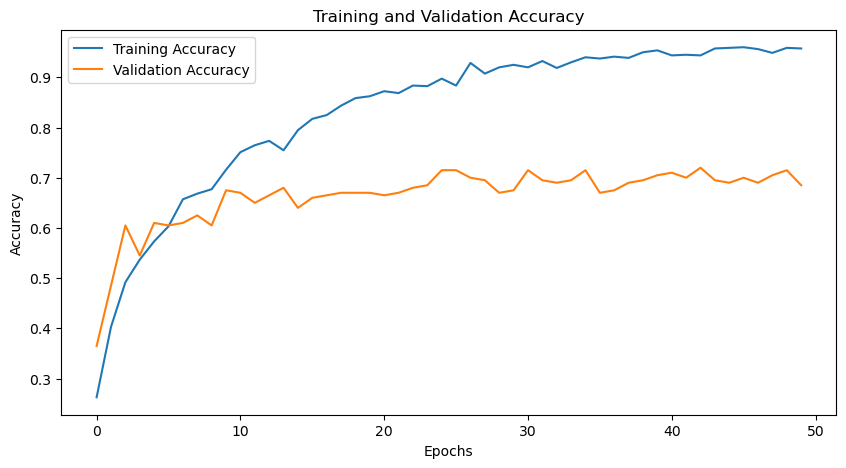

In [20]:
# 12. Plot training and validation accuracy
plt.figure(figsize=(10, 5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step  


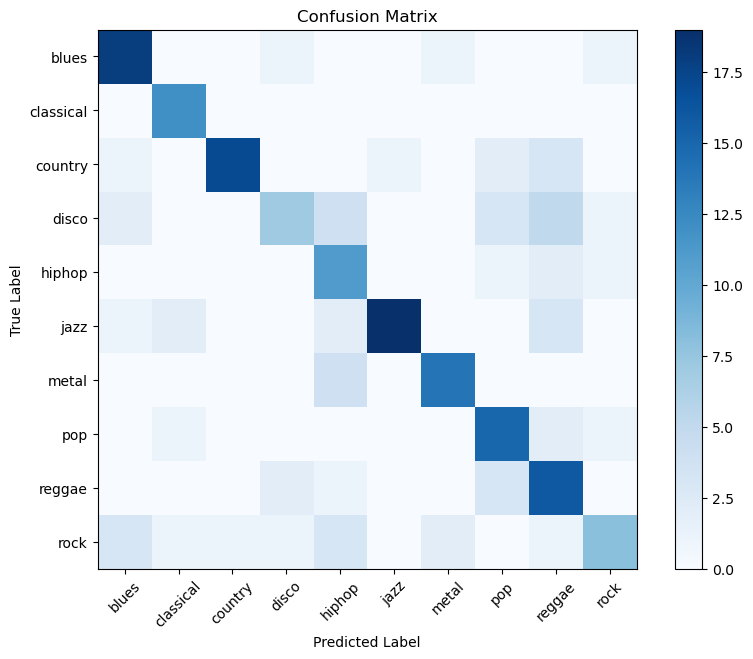

In [ ]:
# 13. Confusion Matrix for test data
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

conf_matrix = confusion_matrix(y_test, y_pred_classes)
plt.figure(figsize=(10, 7))
plt.imshow(conf_matrix, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.colorbar()
plt.xticks(np.arange(len(encoder.classes_)), encoder.classes_, rotation=45)
plt.yticks(np.arange(len(encoder.classes_)), encoder.classes_)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [27]:
# 14. Classification Report
print(classification_report(y_test, y_pred_classes, target_names=encoder.classes_))


              precision    recall  f1-score   support

       blues       0.72      0.86      0.78        21
   classical       0.75      1.00      0.86        12
     country       0.94      0.71      0.81        24
       disco       0.64      0.32      0.42        22
      hiphop       0.44      0.73      0.55        15
        jazz       0.95      0.70      0.81        27
       metal       0.82      0.78      0.80        18
         pop       0.62      0.79      0.70        19
      reggae       0.50      0.73      0.59        22
        rock       0.67      0.40      0.50        20

    accuracy                           0.69       200
   macro avg       0.71      0.70      0.68       200
weighted avg       0.72      0.69      0.68       200



In [23]:
# 15. Save the model
model.save('audio_cnn_model.h5')
print("Model saved as 'audio_cnn_model.h5'")

Model saved as 'audio_cnn_model.h5'
